In [1]:
import pandas as pd
from lifelines import CoxPHFitter

train_clinical = pd.read_csv('/home/yscho/code_cloud_MIL_train/TRAIN_CLINICAL.csv')
test_clinical =  pd.read_csv('/home/yscho/code_cloud_MIL_train/TEST_CLINICAL.csv')
train_risk = pd.read_csv('/home/yscho/code_cloud_MIL_train/TRAIN_RISK_SCORES_FINAL_PNU_1patch_19slide_2year.csv')
test_risk =  pd.read_csv('/home/yscho/code_cloud_MIL_train/TEST_RISK_SCORES_FINAL_PNU_1patch_19slide_2year.csv')

In [2]:
train_clinical

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Patient_no,BCR,BCR interval,Preop_PSA,GS_at_permanent,Margin_status,T_stage_permanent_pathology,Lymphatic invasion_permanent,Perineural_invasion,Op_date,Tumor_Vol_percentage,positive LN개수_permanent_pathology,Age
0,0,0,0,0,511.0,1.0,8.200000,19.657,7.0,1.0,3b,1,0.0,2017-01-09,90.0,0.0,66.0
1,1,1,1,1,877.0,1.0,1.533333,12.200,7.0,1.0,2c,0,NaN,2020-03-26,25.0,0.0,76.0
2,2,2,2,2,854.0,1.0,1.466667,20.400,9.0,1.0,3b,1,NaN,2020-02-06,55.0,5.0,61.0
3,3,3,3,3,350.0,1.0,14.033333,9.660,6.0,1.0,3a,0,NaN,2015-04-30,30.0,0.0,72.0
4,4,4,4,4,638.0,1.0,3.466667,24.100,7.0,1.0,3b,0,NaN,2018-04-30,50.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,557,651,651,651,440.0,0.0,108.912000,33.250,6.0,1.0,3a,0,0.0,2016-04-12,15.0,0.0,62.0
558,558,652,652,652,195.0,0.0,141.372000,6.610,7.0,0.0,2a,0,NaN,2013-07-29,5.0,0.0,71.0
559,559,653,653,653,725.0,0.0,74.678000,NaN,7.0,0.0,3a,0,NaN,2019-02-18,10.0,0.0,64.0
560,560,655,655,655,405.0,0.0,112.756000,2.830,6.0,0.0,2c,0,NaN,2015-12-17,2.0,0.0,76.0


In [3]:
test_clinical

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Patient_no,BCR,BCR interval,Preop_PSA,GS_at_permanent,Margin_status,T_stage_permanent_pathology,Lymphatic invasion_permanent,Perineural_invasion,Op_date,Tumor_Vol_percentage,positive LN개수_permanent_pathology,Age
0,0,0,1,1,1,467.0,1.0,1.300000,40.000,7.0,1.0,3b,0.0,0.0,2016-08-11,29.0,0.0,67.0
1,1,1,6,6,6,331.0,1.0,12.333333,29.850,7.0,0.0,2a,0.0,NaN,2015-02-09,8.0,NaN,66.0
2,2,2,7,7,7,357.0,1.0,1.366667,56.475,7.0,0.0,3a,0.0,NaN,2015-05-27,30.0,0.0,66.0
3,3,3,8,8,8,999.0,1.0,1.633333,12.900,7.0,1.0,3a,0.0,NaN,2021-03-18,10.0,0.0,78.0
4,4,4,9,9,9,824.0,1.0,7.166667,11.500,7.0,1.0,3b,0.0,NaN,2019-12-02,43.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,223,223,256,256,256,167.0,0.0,144.953000,12.080,6.0,0.0,2c,0.0,NaN,2013-04-11,1.0,0.0,71.0
223,224,224,259,259,259,170.0,0.0,144.723000,3.950,7.0,1.0,2c,0.0,NaN,2013-04-18,5.0,0.0,54.0
224,225,225,263,263,263,174.0,0.0,143.901000,3.120,7.0,0.0,2c,0.0,NaN,2013-05-13,10.0,0.0,74.0
225,226,226,264,264,264,175.0,0.0,143.803000,5.380,7.0,0.0,2c,0.0,1.0,2013-05-16,10.0,0.0,65.0


In [4]:
train_risk

,Unnamed: 0,Patient_no,risk_scores,BCR
0,0,523,0.511831,1
1,1,525,0.411257,0
2,2,531,0.073926,0
3,3,538,0.145856,0
4,4,540,0.888656,1
...,...,...,...,...
557,103,489,0.251792,0
558,104,494,0.472581,1
559,105,498,0.210241,0
560,106,507,0.561663,1


In [5]:
test_risk

,Unnamed: 0,Patient_no,risk_scores,BCR
0,0,512,0.792330,1
1,1,2,0.439883,1
2,2,3,0.263624,1
3,3,518,0.752985,1
4,4,7,0.630110,0
...,...,...,...,...
222,222,999,0.787796,1
223,223,1004,0.483140,0
224,224,495,0.432265,0
225,225,1008,0.419047,0


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(
    y_true,
    y_prob,
    n_bootstrap=2000,
    ci=0.95,
    random_state=42,
    verbose=True,
):
    """
    y_true: 1D array-like (0/1 labels)
    y_prob: 1D array-like (predicted probabilities)
    n_bootstrap: bootstrap resampling count (e.g., 2000)
    ci: confidence level (0.95 → 95% CI)
    """

    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n = len(y_true)
    aucs = []

    for i in range(n_bootstrap):
        indices = rng.randint(0, n, n)

        if len(np.unique(y_true[indices])) < 2:
            continue  

        auc = roc_auc_score(y_true[indices], y_prob[indices])
        aucs.append(auc)

    aucs = np.array(aucs)

    alpha = 1 - ci
    lower = np.percentile(aucs, 100 * (alpha / 2))
    upper = np.percentile(aucs, 100 * (1 - alpha / 2))
    mean_auc = np.mean(aucs)

    if verbose:
        print(f"Bootstrap samples used: {len(aucs)}")
        print(f"AUC mean = {mean_auc:.4f}")
        print(f"{int(ci*100)}% CI = [{lower:.4f}, {upper:.4f}]")

    return mean_auc, lower, upper, aucs

import numpy as np
import scipy.stats as stats

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

In [7]:
test_clinical

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Patient_no,BCR,BCR interval,Preop_PSA,GS_at_permanent,Margin_status,T_stage_permanent_pathology,Lymphatic invasion_permanent,Perineural_invasion,Op_date,Tumor_Vol_percentage,positive LN개수_permanent_pathology,Age
0,0,0,1,1,1,467.0,1.0,1.300000,40.000,7.0,1.0,3b,0.0,0.0,2016-08-11,29.0,0.0,67.0
1,1,1,6,6,6,331.0,1.0,12.333333,29.850,7.0,0.0,2a,0.0,NaN,2015-02-09,8.0,NaN,66.0
2,2,2,7,7,7,357.0,1.0,1.366667,56.475,7.0,0.0,3a,0.0,NaN,2015-05-27,30.0,0.0,66.0
3,3,3,8,8,8,999.0,1.0,1.633333,12.900,7.0,1.0,3a,0.0,NaN,2021-03-18,10.0,0.0,78.0
4,4,4,9,9,9,824.0,1.0,7.166667,11.500,7.0,1.0,3b,0.0,NaN,2019-12-02,43.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,223,223,256,256,256,167.0,0.0,144.953000,12.080,6.0,0.0,2c,0.0,NaN,2013-04-11,1.0,0.0,71.0
223,224,224,259,259,259,170.0,0.0,144.723000,3.950,7.0,1.0,2c,0.0,NaN,2013-04-18,5.0,0.0,54.0
224,225,225,263,263,263,174.0,0.0,143.901000,3.120,7.0,0.0,2c,0.0,NaN,2013-05-13,10.0,0.0,74.0
225,226,226,264,264,264,175.0,0.0,143.803000,5.380,7.0,0.0,2c,0.0,1.0,2013-05-16,10.0,0.0,65.0


In [8]:
train_df = pd.merge(train_clinical, train_risk[['Patient_no', 'risk_scores']], on='Patient_no', how='left')
test_df = pd.merge(test_clinical, test_risk[['Patient_no', 'risk_scores']], on='Patient_no', how='left')

train_df = train_df.rename(columns={'Lymphatic invasion_permanent                  ':'Lymphatic invasion_permanent'})
test_df = test_df.rename(columns={'Lymphatic invasion_permanent                  ':'Lymphatic invasion_permanent'})

test_df['Lymphatic invasion_permanent'] = test_df['Lymphatic invasion_permanent'].replace({0.0: '0', 1.0: '1'})

### with clinical variables
col_names = [ 'Patient_no',
 'BCR',
 'BCR interval',
 'Preop_PSA',
 'GS_at_permanent',
 'Margin_status',
 'T_stage_permanent_pathology',
 'Lymphatic invasion_permanent',
 'Op_date',
 'risk_scores',
 'Tumor_Vol_percentage',
 'positive LN개수_permanent_pathology', 
 'Age']

train_df = train_df[col_names]
test_df = test_df[col_names]

### Complete cases
train_df = train_df.dropna(subset=col_names)
test_df = test_df.dropna(subset=col_names)

In [9]:
print(len(train_df))
print(len(test_df))

518
207


In [10]:
import pandas as pd
from lifelines import CoxPHFitter

### with risk scors
col_names_set = [ 
 'Patient_no',
 'BCR',
 'BCR interval',
 'Preop_PSA',
 'GS_at_permanent',
 'Margin_status',
 'T_stage_permanent_pathology',
 'Lymphatic invasion_permanent',
 'risk_scores',
 'Tumor_Vol_percentage',
 'positive LN개수_permanent_pathology', 
 'Age']


### Dummy coding
all_df = pd.concat([train_df[col_names_set], test_df[col_names_set]])
all_dummy = pd.get_dummies(all_df[col_names_set], drop_first=True)

train_dummy = all_dummy[all_dummy['Patient_no'].isin(train_df['Patient_no'])]
test_dummy = all_dummy[all_dummy['Patient_no'].isin(test_df['Patient_no'])]

train_dummy = train_dummy.drop(columns=['Patient_no'])
test_dummy = test_dummy.drop(columns=['Patient_no'])

## AUC, C-index

In [ ]:
mean_auc, ci_low, ci_high, auc_dist = bootstrap_auc_ci(
    y_true=list(test_dummy['BCR']),          
    y_prob=list(test_dummy['risk_scores']),  
    n_bootstrap=2000,
    ci=0.95,
    random_state=0,
)

Bootstrap samples used: 2000
AUC mean = 0.8409
95% CI = [0.7795, 0.8954]


In [14]:
### Calculate C-index
cph = CoxPHFitter(penalizer=0.5)
cph.fit(train_dummy[['BCR', 'BCR interval', 'risk_scores']], duration_col='BCR interval', event_col='BCR')

from lifelines.utils import concordance_index
ph_test = cph.predict_partial_hazard(test_dummy[['BCR', 'BCR interval', 'risk_scores']]).values.ravel()
cidx = concordance_index(test_dummy['BCR interval'], -ph_test, test_dummy['BCR'])
print(f"C-index (test): {cidx:.3f}")

C-index (test): 0.783


## Cox regression

In [11]:
test_dummy

,BCR,BCR interval,Preop_PSA,GS_at_permanent,Margin_status,risk_scores,Tumor_Vol_percentage,positive LN개수_permanent_pathology,Age,T_stage_permanent_pathology_2b,T_stage_permanent_pathology_2c,T_stage_permanent_pathology_3a,T_stage_permanent_pathology_3b,T_stage_permanent_pathology_4,Lymphatic invasion_permanent_1,Lymphatic invasion_permanent_equivocal
0,1.0,1.300000,40.000,7.0,1.0,0.775039,29.0,0.0,67.0,False,False,False,True,False,False,False
2,1.0,1.366667,56.475,7.0,0.0,0.747634,30.0,0.0,66.0,False,False,True,False,False,False,False
3,1.0,1.633333,12.900,7.0,1.0,0.787796,10.0,0.0,78.0,False,False,True,False,False,False,False
4,1.0,7.166667,11.500,7.0,1.0,0.714194,43.0,0.0,54.0,False,False,False,True,False,False,False
5,1.0,1.400000,11.500,9.0,1.0,0.800903,20.0,0.0,75.0,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,0.0,144.953000,12.080,6.0,0.0,0.159988,1.0,0.0,71.0,False,True,False,False,False,False,False
223,0.0,144.723000,3.950,7.0,1.0,0.193493,5.0,0.0,54.0,False,True,False,False,False,False,False
224,0.0,143.901000,3.120,7.0,0.0,0.204099,10.0,0.0,74.0,False,True,False,False,False,False,False
225,0.0,143.803000,5.380,7.0,0.0,0.105924,10.0,0.0,65.0,False,True,False,False,False,False,False


In [12]:
covs = [c for c in test_dummy.columns if c not in ['BCR', 'BCR interval']]
dead = [c for c in covs if test_dummy[c].nunique() < 2]
print('dropped:', dead)
d = test_dummy.drop(columns=dead)

cph = CoxPHFitter(penalizer=0.5)
cph.fit(d, duration_col='BCR interval', event_col='BCR')
cph.print_summary()

dropped: ['T_stage_permanent_pathology_2b', 'T_stage_permanent_pathology_4', 'Lymphatic invasion_permanent_equivocal']


<lifelines.CoxPHFitter: fitted with 207 total observations, 136 right-censored observations>
             duration col = 'BCR interval'
                event col = 'BCR'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 207
number of events observed = 71
   partial log-likelihood = -339.08
         time fit was run = 2026-08-05 01:15:58 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Preop_PSA                          0.00      1.00      0.00           -0.01            0.01                0.99                1.01
GS_at_permanent                    0.25      1.29      0.10            0.06            0.45                1.06                1.57
Margin_status                      0.23      1.26      0.16           -0.09            0.55                0.92                1.73
risk_scores                        1.19      3.27      0.34            0.51            1.86                1.67                6.41
Tumor_Vol_percentage               0.00      1.00      0.00           -0.00            0.01                1.00                1.01
positive LN개수_permanent_pathology -0.56      0.57      0.57           -1.69            0.56                0.18                1.75
Age                               -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
T_stage_permanent_pathology_2c    -0.12      0.89      0.16           -0.44            0.21                0.64                1.23
T_stage_permanent_pathology_3a    -0.00      1.00      0.20           -0.39            0.39                0.68                1.48
T_stage_permanent_pathology_3b     0.12      1.13      0.25           -0.36            0.61                0.69                1.84
Lymphatic invasion_permanent_1     0.55      1.73      0.27            0.01            1.09                1.01                2.97

                                   cmp to     z      p  -log2(p)
covariate                                                       
Preop_PSA                            0.00  0.78   0.43      1.21
GS_at_permanent                      0.00  2.53   0.01      6.47
Margin_status                        0.00  1.43   0.15      2.71
risk_scores                          0.00  3.45 <0.005     10.82
Tumor_Vol_percentage                 0.00  0.85   0.39      1.35
positive LN개수_permanent_pathology    0.00 -0.98   0.33      1.62
Age                                  0.00 -0.14   0.89      0.17
T_stage_permanent_pathology_2c       0.00 -0.71   0.48      1.07
T_stage_permanent_pathology_3a       0.00 -0.01   0.99      0.01
T_stage_permanent_pathology_3b       0.00  0.49   0.62      0.69
Lymphatic invasion_permanent_1       0.00  2.01   0.04      4.50
---
Concordance = 0.80
Partial AIC = 700.16
log-likelihood ratio test = 51.76 on 11 df
-log2(p) of ll-ratio test = 21.66

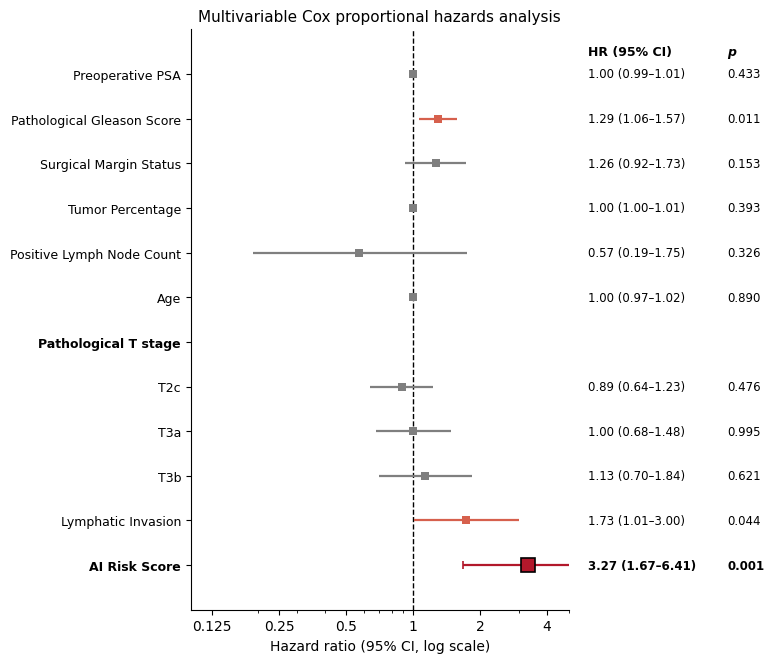

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rows = [
    ("Preoperative PSA",           1.00, 0.99, 1.01, 0.433,  False),
    ("Pathological Gleason Score", 1.29, 1.06, 1.57, 0.011,  False),
    ("Surgical Margin Status",     1.26, 0.92, 1.73, 0.153,  False),
    ("Tumor Percentage",           1.00, 1.00, 1.01, 0.393,  False),
    ("Positive Lymph Node Count",  0.57, 0.19, 1.75, 0.326,  False),
    ("Age",                        1.00, 0.97, 1.02, 0.890,  False),
    ("Pathological T stage",       None, None, None, None,   False),   # 헤더
    ("   T2c",                     0.89, 0.64, 1.23, 0.476,  False),
    ("   T3a",                     1.00, 0.68, 1.48, 0.995,  False),
    ("   T3b",                     1.13, 0.70, 1.84, 0.621,  False),
    ("Lymphatic Invasion",         1.73, 1.01, 3.00, 0.044,  False),
    ("AI Risk Score",              3.27, 1.67, 6.41, 0.001, True),
]

def pfmt(p):
    return "" if p is None else ("<0.001" if p < 0.001 else f"{p:.3f}")

n  = len(rows)
ys = np.arange(n)[::-1]                       

fig, ax = plt.subplots(figsize=(9, 0.52 * n + 1.2))
fig.subplots_adjust(left=0.30, right=0.72, top=0.90, bottom=0.12)

for y, (lab, hr, lo, hi, p, is_ai) in zip(ys, rows):
    if hr is None:                            
        continue
    sig   = p < 0.05
    color = '#B2182B' if is_ai else ('#D6604D' if sig else '#7f7f7f')
    ms    = 10 if is_ai else 6
    ax.errorbar(hr, y, xerr=[[hr - lo], [hi - hr]], fmt='s', color=color,
                markersize=ms, capsize=3, lw=1.6,
                markeredgecolor='black' if is_ai else color,
                markeredgewidth=1.2 if is_ai else 0, zorder=3)

ax.axvline(1.0, ls='--', color='k', lw=1, zorder=1)   
ax.set_xscale('log')
ax.set_xlim(0.1, 5)
ticks = [0.125, 0.25, 0.5, 1, 2, 4]
ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ys); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
for tick, r in zip(ax.get_yticklabels(), rows):
    if r[1] is None or r[5]:                 
        tick.set_fontweight('bold')
ax.set_ylim(-1, n)
ax.set_xlabel('Hazard ratio (95% CI, log scale)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)


tr = ax.get_yaxis_transform()                 
ax.text(1.05, n - 0.5, 'HR (95% CI)', transform=tr, fontsize=9, fontweight='bold', va='center', clip_on=False)
ax.text(1.42, n - 0.5, 'p',           transform=tr, fontsize=9, fontweight='bold', style='italic', va='center', clip_on=False)
for y, (lab, hr, lo, hi, p, is_ai) in zip(ys, rows):
    if hr is None: continue
    w = 'bold' if is_ai else 'normal'
    ax.text(1.05, y, f'{hr:.2f} ({lo:.2f}–{hi:.2f})', transform=tr, fontsize=8.5, va='center', fontweight=w, clip_on=False)
    ax.text(1.42, y, pfmt(p),                         transform=tr, fontsize=8.5, va='center', fontweight=w, clip_on=False)

ax.set_title('Multivariable Cox proportional hazards analysis', fontsize=11)
plt.show()

In [14]:
from lifelines.statistics import proportional_hazard_test
proportional_hazard_test(cph, d, time_transform='rank').print_summary()

## KM plot

In [15]:
train_risk

,Unnamed: 0,Patient_no,risk_scores,BCR
0,0,523,0.511831,1
1,1,525,0.411257,0
2,2,531,0.073926,0
3,3,538,0.145856,0
4,4,540,0.888656,1
...,...,...,...,...
557,103,489,0.251792,0
558,104,494,0.472581,1
559,105,498,0.210241,0
560,106,507,0.561663,1


In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

train_median = train_risk['risk_scores'].median()
train_median

0.45832681655883784

In [17]:
train_risk = pd.merge(train_risk, train_clinical[['Patient_no', 'BCR interval']], on='Patient_no', how='left')
train_risk

,Unnamed: 0,Patient_no,risk_scores,BCR,BCR interval
0,0,523,0.511831,1,11.233333
1,1,525,0.411257,0,97.676000
2,2,531,0.073926,0,96.986000
3,3,538,0.145856,0,96.427000
4,4,540,0.888656,1,3.666667
...,...,...,...,...,...
557,103,489,0.251792,0,101.815000
558,104,494,0.472581,1,11.966667
559,105,498,0.210241,0,101.027000
560,106,507,0.561663,1,1.766667


In [18]:
test_risk = pd.merge(test_risk, test_clinical[['Patient_no', 'BCR interval']], on='Patient_no', how='left')
test_risk

,Unnamed: 0,Patient_no,risk_scores,BCR,BCR interval
0,0,512,0.792330,1,1.433333
1,1,2,0.439883,1,1.400000
2,2,3,0.263624,1,4.400000
3,3,518,0.752985,1,1.466667
4,4,7,0.630110,0,169.889000
...,...,...,...,...,...
222,222,999,0.787796,1,1.633333
223,223,1004,0.483140,0,49.511000
224,224,495,0.432265,0,101.257000
225,225,1008,0.419047,0,49.314000


In [19]:
test_risk['risk_group'] = np.where(test_risk['risk_scores'] > train_median, 'High', 'Low')

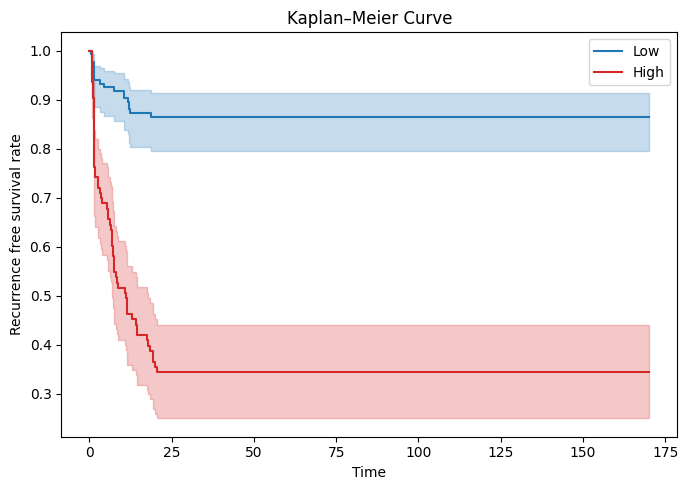

Log-rank p-value (test): 3.154e-17


In [ ]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))
for g, color in [('Low', 'tab:blue'), ('High', 'tab:red')]:
    m = (test_risk['risk_group'] == g)
    kmf.fit(durations=test_risk.loc[m, 'BCR interval'], event_observed=test_risk.loc[m, 'BCR'], label=g)
    kmf.plot_survival_function(ci_show=True, color=color)

plt.title('Kaplan–Meier Curve')
plt.xlabel('Time')
plt.ylabel('Recurrence free survival rate')
plt.tight_layout()
plt.show()

g0 = test_risk[test_risk['risk_group']=='Low']
g1 = test_risk[test_risk['risk_group']=='High']
lr = logrank_test(g0['BCR interval'], g1['BCR interval'], event_observed_A=g0['BCR'], event_observed_B=g1['BCR'])
print(f'Log-rank p-value (test): {lr.p_value:.3e}')

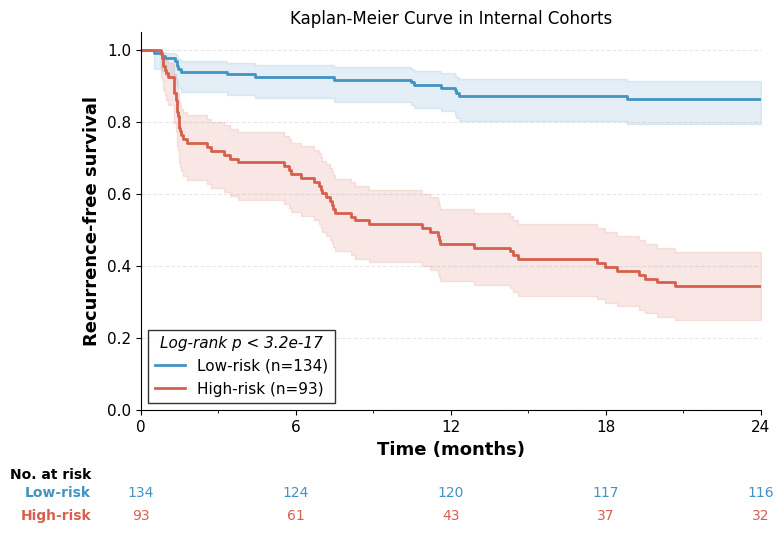

Log-rank p-value: 3.154e-17


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

CUTOFF = 24  # months

test_km = test_risk.copy()
test_km['BCR_censor'] = test_km['BCR interval'].clip(upper=CUTOFF)
test_km['BCR_event'] = (test_km['BCR'] == 1) & (test_km['BCR interval'] <= CUTOFF)

g0 = test_km[test_km['risk_group'] == 'Low']
g1 = test_km[test_km['risk_group'] == 'High']
lr = logrank_test(
    g0['BCR_censor'], g1['BCR_censor'],
    event_observed_A=g0['BCR_event'], event_observed_B=g1['BCR_event']
)

if lr.p_value < 0.001:
    p_text = f'Log-rank p < {lr.p_value:.1e}'
else:
    p_text = f'Log-rank p = {lr.p_value:.3f}'

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Low': '#4393C3', 'High': '#D6604D'}  # colorblind-friendly
kmf_objects = {}

for g in ['Low', 'High']:
    m = test_km['risk_group'] == g
    n = m.sum()
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=test_km.loc[m, 'BCR_censor'],
        event_observed=test_km.loc[m, 'BCR_event'],
        label=f'{g}-risk (n={n})'
    )
    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,
        color=colors[g],
        linewidth=2,
        ci_alpha=0.15
    )
    kmf_objects[g] = kmf

# 축 설정
ax.set_xlim(0, CUTOFF)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Time (months)', fontsize=13, fontweight='bold')
ax.set_ylabel('Recurrence-free survival', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(3))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='both', which='major', labelsize=11)

handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles, labels,
    loc='lower left',
    fontsize=11,
    frameon=True,
    fancybox=False,
    edgecolor='black',
    title=p_text,
    title_fontsize=11,
)
legend.get_title().set_fontstyle('italic')

# grid
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

risk_times = [0, 6, 12, 18, 24]
table_data = {}
for g in ['Low', 'High']:
    m = test_km['risk_group'] == g
    durations = test_km.loc[m, 'BCR_censor'].values
    events = test_km.loc[m, 'BCR_event'].values
    n_at_risk = []
    for t in risk_times:
        n_at_risk.append(int((durations >= t).sum()))
    table_data[g] = n_at_risk

table_y_start = -0.22
row_height = 0.06

for i, (g, label_color) in enumerate([('Low', colors['Low']), ('High', colors['High'])]):
    y_pos = table_y_start - i * row_height
    ax.text(-0.08, y_pos, f'{g}-risk', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=label_color,
            ha='right', va='center')
    for j, t in enumerate(risk_times):
        x_pos = t / CUTOFF
        ax.text(x_pos, y_pos, str(table_data[g][j]), transform=ax.transAxes,
                fontsize=10, ha='center', va='center', color=label_color)

ax.text(-0.08, table_y_start + row_height * 0.8, 'No. at risk', transform=ax.transAxes,
        fontsize=10, fontweight='bold', ha='right', va='center')

plt.subplots_adjust(bottom=0.25)
plt.title("Kaplan-Meier Curve in Internal Cohorts")
plt.savefig('km_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('/home/yscho/code_cloud_MIL_train/Scientific_report_figures/KM_plot_internal_test.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f'Log-rank p-value: {lr.p_value:.3e}')

## Calibration & DCA

분석 대상: 207명 | BCR within 2yr: 71, Non-BCR: 136
Brier Score: 0.1576


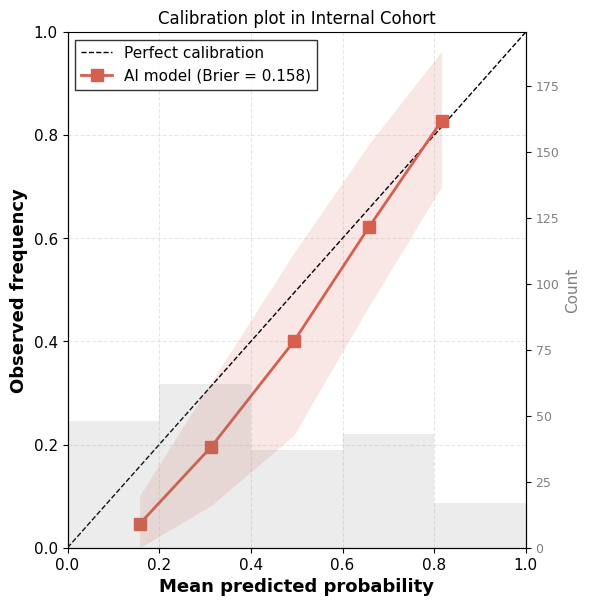

Brier Score: 0.1576


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss

# --- 2-year BCR label ---
y_true = ((test_dummy['BCR'] == 1) & (test_dummy['BCR interval'] <= 24)).astype(int).values
y_prob = test_dummy['risk_scores'].values          # AI softmax probability
N = len(y_true)
print(f'분석 대상: {N}명 | BCR within 2yr: {y_true.sum()}, Non-BCR: {(y_true==0).sum()}')

brier = brier_score_loss(y_true, y_prob)
print(f'Brier Score: {brier:.4f}')

# ===== 5 equal-width (uniform) bins, fixed on full data =====
n_bins, n_boot, seed = 5, 500, 0
edges = np.linspace(y_prob.min(), y_prob.max(), n_bins + 1)
edges[0] -= 1e-9; edges[-1] += 1e-9
binid = np.digitize(y_prob, edges) - 1
nb = len(edges) - 1

xm = np.array([y_prob[binid == b].mean() if np.any(binid == b) else np.nan for b in range(nb)])
ym = np.array([y_true[binid == b].mean() if np.any(binid == b) else np.nan for b in range(nb)])

# ===== bootstrap 95% CI per fixed bin (500 resamples) =====
rng = np.random.default_rng(seed)
boots = np.full((n_boot, nb), np.nan)
for i in range(n_boot):
    idx = rng.integers(0, N, N)
    bb, yy = binid[idx], y_true[idx]
    for b in range(nb):
        m = bb == b
        if m.any():
            boots[i, b] = yy[m].mean()
lo, hi = np.nanpercentile(boots, [2.5, 97.5], axis=0)

# ===== plot =====
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

ok = ~np.isnan(xm)
order = np.argsort(xm[ok])
xx, yy2, ll, hh = xm[ok][order], ym[ok][order], lo[ok][order], hi[ok][order]
ax.fill_between(xx, ll, hh, color='#D6604D', alpha=0.15, lw=0)              # 음영 95% CI
ax.plot(xx, yy2, 's-', color='#D6604D', linewidth=2, markersize=8,
        label=f'AI model (Brier = {brier:.3f})')

ax_hist = ax.twinx()
ax_hist.hist(y_prob, bins=5, range=(0, 1), alpha=0.15, color='gray', edgecolor='none')
ax_hist.set_ylabel('Count', fontsize=11, color='gray')
ax_hist.tick_params(axis='y', labelcolor='gray', labelsize=9)
ax_hist.set_ylim(0, ax_hist.get_ylim()[1] * 3)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability', fontsize=13, fontweight='bold')
ax.set_ylabel('Observed frequency', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(loc='upper left', fontsize=11, frameon=True, fancybox=False, edgecolor='black')
ax.grid(True, which='major', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.title("Calibration plot in Internal Cohort")
plt.show()
print(f'Brier Score: {brier:.4f}')

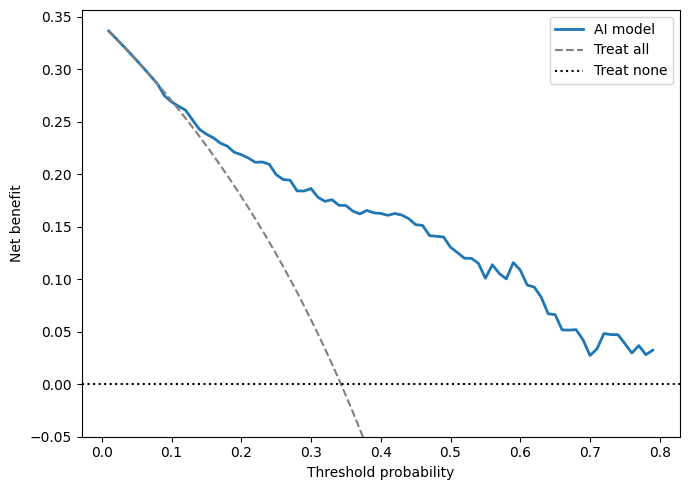

In [ ]:
import numpy as np, matplotlib.pyplot as plt

df = test_dummy.copy()
y = df['BCR'].astype(int).values                
p = df['risk_scores'].values                    
N = len(y); prev = y.mean()

thr = np.arange(0.01, 0.80, 0.01)                 
nb_model, nb_all = [], []
for pt in thr:
    pred = p >= pt
    TP = np.sum(pred & (y == 1)); FP = np.sum(pred & (y == 0))
    w = pt / (1 - pt)
    nb_model.append(TP/N - FP/N * w)              
    nb_all.append(prev - (1 - prev) * w)          
nb_model, nb_all = np.array(nb_model), np.array(nb_all)

plt.figure(figsize=(7, 5))
plt.plot(thr, nb_model, lw=2, label='AI model')
plt.plot(thr, nb_all, ls='--', color='gray', label='Treat all')
plt.axhline(0, ls=':', color='k', label='Treat none')
plt.ylim(-0.05, max(nb_model.max(), nb_all.max()) + 0.02)
plt.xlabel('Threshold probability'); plt.ylabel('Net benefit')
plt.legend(); plt.tight_layout()